# 10 — Synthetic Data Generation

More data, better model — but only if the data is correct. This notebook generates
synthetic ARO programs at scale and uses the actual runtime as the quality signal.

The model explores many candidates at different temperatures (GRPO-style), scores
them with `aro check` + `aro run`, and saves only the ones that work. Every 30 valid
samples, a LoRA fine-tune round runs on all accumulated successes and the improved
adapter is hot-reloaded — so the model gets better at ARO *while it generates*.

**Why the warm-start matters here:** a cold base model fails `aro check` on most
attempts, so the explore loop never accumulates enough data to fine-tune.
The warm-start adapter from notebook 04 gives the model enough ARO fluency to
succeed often enough for the RL loop to kick in and compound.

**Inputs:**
- `../data/02_knowledge/knowledge.json`
- `../data/02_knowledge/knowledge_pairs.jsonl` — curated pairs used as few-shot context

**Output:** `../data/03_raw_generated/samples.jsonl`

**Seven task types (targets vs actual last run):**

| Task | Target | Actual |
|------|-------:|-------:|
| `code_generation` | 200 | 361 |
| `syntax_qa` | 150 | 150 |
| `fim` | 200 | 200 |
| `code_explanation` | 150 | 104 |
| `debugging` | 120 | 62 |
| `translation` | 80 | 2 |
| `architecture` | 60 | 1 |
| **Total** | **960** | **880** |

Under-target tasks (translation, architecture, debugging) reflect lower pass rates
through `aro check` — they require more valid ARO structure and the model struggles
more at these. Over-target code_generation reflects higher success rates.

In [1]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'mlx-lm'], check=False)

CompletedProcess(args=['pip', 'install', '-q', 'mlx-lm'], returncode=0)

In [ ]:
import sys, importlib
from pathlib import Path
_cfg_dir = Path('.').resolve()
if _cfg_dir not in [Path(p) for p in sys.path]:
    sys.path.insert(0, str(_cfg_dir))
import config; importlib.reload(config); from config import *
print(f'Config loaded | model={MODEL_ID}')
print(f'ARO root:  {ARO_ROOT}')
print(f'Pairs:     {PAIRS_FILE}')
print(f'Adapters:  {ADAPTER_DIR}')

import json
import re
import sys
import random
import subprocess
import tempfile
import importlib
from pathlib import Path
from collections import Counter

def ensure_mlx_lm():
    try:
        from mlx_lm import load, generate as mlx_generate
        return load, mlx_generate
    except ModuleNotFoundError:
        print("mlx_lm not found in the current kernel environment. Installing...")
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", "mlx-lm"],
            capture_output=True,
            text=True
        )
        if result.returncode != 0:
            raise RuntimeError(
                "Failed to install mlx-lm in the current Python environment.\n"
                f"stdout:\n{result.stdout}\n\nstderr:\n{result.stderr}"
            )

        importlib.invalidate_caches()

        try:
            from mlx_lm import load, generate as mlx_generate
            return load, mlx_generate
        except ModuleNotFoundError as e:
            raise RuntimeError(
                "mlx-lm was installed, but the current Jupyter kernel still cannot import it.\n"
                "Please restart the notebook kernel and rerun the notebook."
            ) from e

load, mlx_generate = ensure_mlx_lm()

DATA_OUT = GLOBAL_OUT_DIR / '../data/03_raw_generated'
DATA_OUT.mkdir(parents=True, exist_ok=True)

# --- Model config ---
# MoE model: 30B params but only ~3.3B active — fits in 8 GB unified memory.

TARGETS = {
    'code_generation':  300,   # was 200
    'fim':              250,   # was 200
    'syntax_qa':        150,
    'code_explanation': 200,   # was 150
    'debugging':        180,   # was 120
    # translation: DISABLED — 2.5% success rate
    # architecture: DISABLED — 1.7% success rate
}

MAX_REPAIR_ATTEMPTS = 3   # retries per sample before discarding

with open(DATA_IN / 'knowledge.json') as f:
    kb = json.load(f)

print(f'Knowledge base: {len(kb["actions"])} actions, {len(kb["examples"])} examples')

## Load model

In [3]:
print(f'Loading {MODEL_ID}...')

# Auto-load warm-start adapter from notebook 04 if it exists.
# Notebook 04 writes the adapter path into knowledge.json after its fine-tune cell runs.
_warm_adapter = None
_kb_path = DATA_IN / 'knowledge.json'
if _kb_path.exists():
    try:
        with open(_kb_path) as _f:
            _kb_meta = json.load(_f)
        _warm_path = Path(_kb_meta.get('warm_start_adapter', ''))
        if _warm_path.exists() and (_warm_path / 'adapters.safetensors').exists():
            _warm_adapter = str(_warm_path)
            print(f'Found warm-start adapter: {_warm_adapter}')
    except Exception as _e:
        print(f'Could not read warm-start adapter path: {_e}')

if _warm_adapter:
    model, tokenizer = load(MODEL_ID, adapter_path=_warm_adapter)
    print(f'Model loaded with warm-start adapter (from notebook 04).')
else:
    model, tokenizer = load(MODEL_ID)
    print('Model loaded (base weights — run notebook 04 first for warm-start fine-tuning).')

# Propagate warm-start adapter into RL state so fine-tune rounds build on it
# (this variable is read by the RL config cell which also declares _rl_adapter)
_warm_start_adapter_path = Path(_warm_adapter) if _warm_adapter else None
print('Model ready.')

Loading mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit...
Found warm-start adapter: /Volumes/Models/data/../data/adapters/warm_start


Fetching 15 files: 100%|██████████| 15/15 [00:00<00:00, 24.84it/s]


Model loaded with warm-start adapter (from notebook 04).
Model ready.


## System prompt (built from extracted action knowledge)

In [ ]:
ARO_SYSTEM_PROMPT = """You are an expert ARO language programmer.
ARO (Action Result Object) is a DSL for expressing business logic as natural-language statements.

SYNTAX:
  (FeatureSetName: BusinessActivity) {
      Verb [the] <result[:qualifier]> preposition [the] <object[:qualifier]>.
  }

KEY RULES:
- Articles (a/an/the) are optional everywhere
- String concatenation: ++ (NOT +)
- Variable names: hyphenated lowercase e.g. <user-id>, <order-total>
- Forbidden variable name prefixes: is-, with-, empty-
- Variables are IMMUTABLE — bind once; use a new name for each transformation
- Exactly ONE Application-Start per application (error if 0 or multiple)
- openapi.yaml REQUIRED for HTTP server; operationId must match feature set name
- Long-running apps: Keepalive the <application> for the <events>.

HTTP:
- Path params:   Extract the <id> from the <pathParameters: id>.
- Request body:  Extract the <data> from the <request: body>.
- Return statuses: <OK: status>, <Created: status>, <NoContent: status>,
                   <NotFound: status>, <BadRequest: status>, <Conflict: status>,
                   <Unauthorized: status>, <InternalServerError: status>

CONTROL FLOW:
- Conditional:   when <condition> { statements }
- Loop:          For each <item> in <list> { statements }
- Match:         match <var> { case value { statements } case other { statements } }
- Guard on declaration: (Name: EventName Handler) when <field> = value { ... }

COMPUTE & ARITHMETIC:
- Compute the <total> from <price> * <qty>.
- Compute the <upper: uppercase> from <text>.
- Compute the <len: length> from <text>.
- Supported ops: +, -, *, /, % (integers); ++ (strings)

CROSS-FEATURE SHARING:
- Publish as <alias> <variable>.  (makes variable accessible across feature sets in same business activity)

EVENTS:
- Emit a <EventName: event> with <data>.
- Handler:  (HandlerName: EventName Handler) { ... }
- State:    Accept the <new-state: toState> for the <entity>.

LIFECYCLE:
- Application-Start: required entry point
- Application-End: Success (optional graceful shutdown)
- Application-End: Error (optional crash handler)

AVAILABLE ACTIONS (verb → role → prepositions):
- Extract     REQUEST   from/with     — pull data from request/event/object
- Retrieve    REQUEST   from/where    — fetch from repository or service
- Fetch       REQUEST   from/with     — HTTP GET external URL
- Parse       REQUEST   from          — parse JSON/YAML/HTML/CSV text
- Request     REQUEST   from/with     — HTTP POST/PUT/PATCH
- Compute     OWN       from/with/for — arithmetic, string ops, built-in transforms
- Transform   OWN       from/with     — type coercion (e.g. string → int)
- Validate    OWN       for/with      — check constraints, return bool
- Compare     OWN       against/with  — compare two values, return bool
- Create      OWN       with          — instantiate struct or entity
- Merge       OWN       with          — combine objects or collections
- Filter      OWN       where/with    — select subset of collection
- Sort        OWN       by/with       — order a collection
- Split       OWN       by/from       — split string or list by delimiter
- Join        OWN       with/from     — join strings or list elements
- Accept      OWN       with/for      — state machine transition
- Return      RESPONSE  with/for      — send HTTP response and end feature set
- Throw       RESPONSE  with/for      — raise exception (propagates as error)
- Store       EXPORT    into          — persist to repository (auto-generates id)
- Update      EXPORT    into          — update existing record in repository
- Delete      EXPORT    from          — remove record from repository
- Log         EXPORT    to            — write to console or log service
- Send        EXPORT    to/with       — send email or message
- Emit        EXPORT    with          — publish domain event to EventBus
- Publish     EXPORT    as            — share variable across feature sets
- Start       EXPORT    with          — start a service (HTTP server, file monitor)
- Stop        EXPORT    with          — stop a running service
- Keepalive   EXPORT    for           — block until shutdown signal (for servers)
- Render      EXPORT    with/using    — render Mustache template
- Notify      EXPORT    with          — send notification to user(s)
- Configure   EXPORT    with          — set runtime configuration option
- Read        REQUEST   from          — read file contents
- Write       EXPORT    to            — write data to file
- Copy        EXPORT    to            — copy file to destination
- Move        EXPORT    to            — move file to destination

Always wrap ARO code in ```aro ... ``` fences.
Always generate complete, valid ARO that would pass `aro check`.
"""

print(f'System prompt: {len(ARO_SYSTEM_PROMPT)} chars')

## Core helpers

In [5]:
def chat(messages, max_tokens=1500):
    """Run the model on a message list and return the response string."""
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    return mlx_generate(model, tokenizer, prompt=prompt, max_tokens=max_tokens, verbose=False)

def extract_aro_blocks(text):
    return [b.strip() for b in re.findall(r'```aro\n(.*?)```', text, re.DOTALL) if b.strip()]

def aro_check(code):
    """Returns (True/False/None, error_str). None = aro not available."""
    try:
        with tempfile.TemporaryDirectory() as tmp:
            (Path(tmp) / 'main.aro').write_text(code)
            r = subprocess.run(['aro', 'check', tmp], capture_output=True, text=True, timeout=10)
            return r.returncode == 0, (r.stderr or r.stdout).strip()[:300]
    except FileNotFoundError:
        return None, 'aro_not_found'
    except subprocess.TimeoutExpired:
        return False, 'timeout'

def generate_with_repair(instruction, max_tokens=1500, label=''):
    """
    Generate ARO code. On aro check failure, feed the error back and retry.
    Returns (output_str, attempts_used) or (None, MAX_REPAIR_ATTEMPTS) if all fail.
    """
    messages = [
        {'role': 'system', 'content': ARO_SYSTEM_PROMPT},
        {'role': 'user',   'content': instruction},
    ]

    for attempt in range(MAX_REPAIR_ATTEMPTS):
        tag = f'    [attempt {attempt+1}/{MAX_REPAIR_ATTEMPTS}]{(" " + label) if label else ""}'
        print(f'{tag} generating...', flush=True)
        output = chat(messages, max_tokens=max_tokens)

        # Short preview of raw output
        preview = ' '.join(output.split())[:140]
        print(f'{tag} → {preview}', flush=True)

        blocks = extract_aro_blocks(output)

        if not blocks:
            print(f'{tag} ✗ no ```aro``` block — retrying', flush=True)
            messages += [
                {'role': 'assistant', 'content': output},
                {'role': 'user',      'content': 'No ```aro``` block found. Please wrap your ARO code in ```aro\n...\n```.'},
            ]
            continue

        passed, error = aro_check('\n\n'.join(blocks))

        if passed is True or passed is None:   # valid or aro not available → accept
            label_str = 'check passed' if passed is True else 'aro not available (accepted)'
            print(f'{tag} ✓ {label_str}', flush=True)
            return output, attempt

        # Feed the error back for self-repair
        print(f'{tag} ✗ check failed: {error[:120]}', flush=True)
        messages += [
            {'role': 'assistant', 'content': output},
            {'role': 'user',      'content':
                f'`aro check` returned this error:\n\n```\n{error}\n```\n\nPlease fix the ARO code and try again.'},
        ]

    print(f'    [discarded]{(" " + label) if label else ""} all {MAX_REPAIR_ATTEMPTS} attempts failed', flush=True)
    return None, MAX_REPAIR_ATTEMPTS   # gave up


In [ ]:
def _show_sample(pairs, n=2, label=''):
    import random as _r
    sample_pool = _r.sample(pairs, min(n, len(pairs)))
    print(f'\n── Sample ({label}, {len(pairs)} total) ──────────────────────')
    for i, s in enumerate(sample_pool, 1):
        if 'messages' in s:
            user = s['messages'][1]['content'] if len(s['messages']) > 1 else ''
            asst = s['messages'][2]['content'] if len(s['messages']) > 2 else ''
        else:
            user = s.get('instruction', s.get('user', ''))
            asst = s.get('output', s.get('assistant', ''))
        task = s.get('task_type', s.get('source', '?'))
        print(f'  [{i}] task={task}')
        print(f'       USER: {user[:120].strip()!r}')
        print(f'       ASST: {asst[:120].strip()!r}')
    print('─' * 60)

## Output file + resume support

In [6]:
OUTPUT_FILE = DATA_OUT / 'samples.jsonl'

def save(sample):
    with open(OUTPUT_FILE, 'a') as f:
        f.write(json.dumps(sample) + '\n')

# Resume: track which keys are already done
done = set()
if OUTPUT_FILE.exists():
    with open(OUTPUT_FILE) as f:
        for line in f:
            try:
                s = json.loads(line)
                done.add((s['task_type'], s.get('domain', s.get('source', s.get('scenario', s.get('heading', ''))))))
            except Exception:
                pass
    print(f'Resuming — {len(done)} samples already saved')

repair_stats = Counter()

Resuming — 92 samples already saved


## Reinforcement Learning: Explore & Learn

The model learns ARO by exploring — generating multiple candidates at varying temperatures,
validating each with `aro check` and `aro run`, and saving the ones that work as training data.
Every **30 valid samples**, a LoRA SFT round runs on all accumulated valid examples.
The improved adapter is hot-reloaded, so subsequent generation benefits immediately.

```
docs + proposals + examples
        │
        ▼
  explore K candidates          ← four temperatures per prompt
  (aro check + aro run)         ← real tool feedback, not proxy metrics
        │
  score ≥ 0.6?
   YES  ──→ save to samples.jsonl (becomes training data)
   NO   ──→ generate_with_repair fallback
        │
  every 30 valid samples
        ──→ LoRA SFT fine-tune on all saved samples
        ──→ hot-reload model with new adapter
        ──→ repeat (model gets better at ARO over time)
```

In [7]:
# RL: Explore & Learn configuration
K_EXPLORE      = 4                       # candidates per prompt (one per temperature)
EXPLORE_TEMPS  = [0.3, 0.6, 0.9, 1.1]   # varied temperatures for exploration
FINETUNE_EVERY = 30                      # new valid samples before a LoRA round
LORA_LAYERS    = 8                       # LoRA adapter depth

ADAPTER_DIR  = DATA_OUT.parent / 'adapters'
SFT_DATA_DIR = DATA_OUT.parent / 'sft_data'
ADAPTER_DIR.mkdir(parents=True, exist_ok=True)
SFT_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Mutable state (updated by run_rl_finetune)
_rl_adapter        = None   # Path to current adapter, or None (base model)
_rl_round          = 0      # Fine-tune round counter
_samples_since_tune = 0     # New valid samples since last fine-tune
_rl_losses         = {}     # {round: {train_iters, train_losses, val_iters, val_losses}}

# Inherit warm-start adapter as the starting point for RL rounds
if '_warm_start_adapter_path' in dir() and _warm_start_adapter_path:
    _rl_adapter = _warm_start_adapter_path
    print(f'RL starting from warm-start adapter: {_rl_adapter}')

print(f'RL config: K={K_EXPLORE} temps={EXPLORE_TEMPS} finetune_every={FINETUNE_EVERY}')


RL starting from warm-start adapter: /Volumes/Models/data/../data/adapters/warm_start
RL config: K=4 temps=[0.3, 0.6, 0.9, 1.1] finetune_every=30


In [8]:
def aro_run_validate(code, timeout=10):
    """
    Run code with `aro run` and return (ok, output_str).
      True  = ran cleanly
      True  = timed out (likely a server app — that's valid)
      False = crashed with non-zero exit
      None  = aro binary not found
    """
    try:
        with tempfile.TemporaryDirectory() as tmp:
            (Path(tmp) / 'main.aro').write_text(code)
            r = subprocess.run(
                ['aro', 'run', tmp],
                capture_output=True, text=True, timeout=timeout,
            )
            out = (r.stdout + r.stderr).strip()
            return (r.returncode == 0), out[:300]
    except FileNotFoundError:
        return None, 'aro not found'
    except subprocess.TimeoutExpired:
        return True, 'server_timeout'


def score_candidate(raw_output):
    """
    Score a raw model output using aro check + aro run.
    Returns (score: float, detail: str).

      0.0  no ARO block at all
      0.1  has ARO block but aro check failed
      0.5  aro not available (neutral — structural signal only)
      0.8  aro check passed; run skipped (server/Keepalive app)
      0.9  aro check passed; run unavailable
      1.0  aro check passed AND aro run succeeded
    """
    blocks = extract_aro_blocks(raw_output)
    if not blocks:
        return 0.0, 'no_aro_block'

    code = '\n\n'.join(blocks)
    check_ok, check_err = aro_check(code)

    if check_ok is None:
        return 0.5, 'aro_unavailable'
    if not check_ok:
        short = check_err.split('\n')[0][:80]
        return 0.1, f'check_failed: {short}'

    # Check passed — skip run for long-running server apps
    if 'Keepalive' in code or 'http-server' in code:
        return 0.8, 'check_passed (server — run skipped)'

    run_ok, run_out = aro_run_validate(code)
    if run_ok is None:
        return 0.9, 'check_passed (run unavailable)'
    if run_ok:
        short = run_out.split('\n')[0][:60]
        return 1.0, f'check+run passed: {short}'
    short = run_out.split('\n')[0][:60]
    return 0.8, f'check_passed run_failed: {short}'

print('Validation functions ready.')


Validation functions ready.


In [9]:
from mlx_lm.sample_utils import make_sampler


def explore_candidates(instruction, max_tokens=1500):
    """
    GRPO-style exploration: sample K candidates at different temperatures.
    Returns list of (output, score, detail) sorted best-first.
    The best-scoring candidate that passes aro check becomes training data.
    """
    messages = [
        {'role': 'system', 'content': ARO_SYSTEM_PROMPT},
        {'role': 'user',   'content': instruction},
    ]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    results = []
    for i, temp in enumerate(EXPLORE_TEMPS[:K_EXPLORE]):
        print(f'    [explore {i+1}/{K_EXPLORE} T={temp:.1f}] generating...', flush=True)
        output = mlx_generate(
            model, tokenizer, prompt=prompt,
            max_tokens=max_tokens, verbose=False,
            sampler=make_sampler(temp=temp),
        )
        score, detail = score_candidate(output)
        preview = ' '.join(output.split())[:130]
        print(f'    [explore {i+1}] score={score:.1f}  {detail}', flush=True)
        print(f'    [explore {i+1}] → {preview}', flush=True)
        results.append((output, score, detail))

    results.sort(key=lambda x: -x[1])
    return results


In [10]:
def run_rl_finetune():
    """
    Fine-tune on all valid samples accumulated in samples.jsonl (LoRA SFT).
    Frees the model from memory, runs mlx_lm lora in a subprocess,
    then hot-reloads with the new adapter so subsequent generation benefits.
    """
    global model, tokenizer, _rl_adapter, _rl_round, _rl_losses

    _rl_round += 1
    adapter_out = ADAPTER_DIR / f'round_{_rl_round:03d}'

    # Build SFT chat-format data from every valid sample saved so far
    samples = []
    if OUTPUT_FILE.exists():
        with open(OUTPUT_FILE) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                s = json.loads(line)
                instr  = s.get('instruction', '')
                output = s.get('output', '')
                if instr and output:
                    samples.append({'messages': [
                        {'role': 'system',    'content': ARO_SYSTEM_PROMPT},
                        {'role': 'user',      'content': instr},
                        {'role': 'assistant', 'content': output},
                    ]})

    if len(samples) < 4:
        print(f'  [RL] Skipping fine-tune — only {len(samples)} samples (need ≥ 4)', flush=True)
        return

    random.shuffle(samples)
    split = max(1, int(len(samples) * 0.1))

    SFT_DATA_DIR.mkdir(parents=True, exist_ok=True)
    (SFT_DATA_DIR / 'valid.jsonl').write_text(
        '\n'.join(json.dumps(s) for s in samples[:split]))
    (SFT_DATA_DIR / 'train.jsonl').write_text(
        '\n'.join(json.dumps(s) for s in samples[split:]))

    # Scale steps: roughly 2 passes over the data, min 50 max 200
    iters = max(50, min(200, len(samples) * 2))

    cmd = [
        sys.executable, '-m', 'mlx_lm', 'lora',
        '--model',         MODEL_ID,
        '--data',          str(SFT_DATA_DIR),
        '--train',
        '--num-layers',    str(LORA_LAYERS),
        '--iters',         str(iters),
        '--batch-size',    '2',
        '--learning-rate', '2e-4',
        '--adapter-path',  str(adapter_out),
        '--mask-prompt',
    ]
    if _rl_adapter:
        cmd += ['--resume-adapter-file',
                str(_rl_adapter / 'adapters.safetensors')]

    print(f'\n  [RL round {_rl_round}] fine-tuning on {len(samples)} samples, {iters} steps...', flush=True)

    # Free unified memory before the subprocess training run
    del model, tokenizer
    import gc, re as _re
    gc.collect()

    # Stream output in real-time — avoids timeout on large models; also parses losses
    _loss_re = _re.compile(r'Iter\s+(\d+):\s+(Train|Val) loss\s+([\d.]+)')
    round_losses = {'train_iters': [], 'train_losses': [], 'val_iters': [], 'val_losses': []}

    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    for line in proc.stdout:
        print(f'  [RL] {line}', end='', flush=True)
        m = _loss_re.search(line)
        if m:
            it, kind, val = int(m.group(1)), m.group(2), float(m.group(3))
            if kind == 'Train':
                round_losses['train_iters'].append(it)
                round_losses['train_losses'].append(val)
            else:
                round_losses['val_iters'].append(it)
                round_losses['val_losses'].append(val)
    returncode = proc.wait()

    _rl_losses[_rl_round] = round_losses

    if returncode == 0:
        _rl_adapter = adapter_out
        print(f'  [RL] Training complete → {adapter_out}', flush=True)
    else:
        print(f'  [RL] Training failed (round {_rl_round}) with exit code {returncode}', flush=True)
        # Fall back to last known good adapter (or base)

    # Hot-reload: base model + adapter fused in-memory (no disk write needed)
    load_kwargs = {'adapter_path': str(_rl_adapter)} if _rl_adapter else {}
    model, tokenizer = load(MODEL_ID, **load_kwargs)
    print(f'  [RL] Model reloaded'
          + (f' with adapter (round {_rl_round})' if _rl_adapter else ' (base weights)'),
          flush=True)


In [11]:
# ── Grounded domains: load (instruction, reference_code) from real Examples ──
# Produced by notebook 03 Phase 1. Each entry has a known-correct ARO solution,
# so we can measure how close the model gets and always save the reference as
# ground-truth training data regardless of what the model generates.

GROUNDED_DOMAINS = []

_kp_file = DATA_IN / 'knowledge_pairs.jsonl'
if _kp_file.exists():
    with open(_kp_file) as _f:
        for _line in _f:
            if not _line.strip():
                continue
            try:
                _p = json.loads(_line)
                if _p.get('source', '').startswith('example:'):
                    GROUNDED_DOMAINS.append({
                        'instruction': _p['instruction'],
                        'reference':   _p.get('output', _p.get('messages',[{}]*3)[2].get('content','')),  # real, validated ARO code
                        'name':        _p.get('source', '').split(':', 1)[1],
                    })
            except Exception:
                pass
    print(f'Loaded {len(GROUNDED_DOMAINS)} grounded domains from real examples')
    print('These are interleaved 1:3 with synthetic domains in Task 1.')
    print('For each, the reference solution is always saved as score=1.0 training data.')
else:
    print('No knowledge_pairs.jsonl found — run notebooks 03 and 04 first.')
    print('Task 1 will use synthetic domains only.')


def _feature_set_names(code):
    """Extract the set of feature-set names from ARO code."""
    return set(re.findall(r'\(\s*([^:)]+?)\s*:', code))


def _reference_similarity(generated_output, reference_output):
    """
    Fraction of reference feature-set names reproduced in the generated output.
    1.0 = all reference feature sets present, 0.0 = none.
    """
    ref_names = _feature_set_names(reference_output)
    gen_names = _feature_set_names(generated_output)
    if not ref_names:
        return 0.5
    return round(len(ref_names & gen_names) / len(ref_names), 3)


def _grounded_prompt(domain_info):
    """
    Build a reference-guided instruction: the model sees the real example
    as a pattern guide before being asked to write the new application.
    """
    ref_preview = domain_info['reference'][:2000]
    return (
        f'{domain_info["instruction"]}\n\n'
        f'Study this working ARO example to learn the correct patterns:\n\n'
        f'{ref_preview}\n\n'
        f'Now write the complete ARO application described in the instruction above, '
        f'following the same structural patterns.'
    )


Loaded 105 grounded domains from real examples
These are interleaved 1:3 with synthetic domains in Task 1.
For each, the reference solution is always saved as score=1.0 training data.


## Task 1 — Code Generation

In [12]:
DOMAINS = [
    'todo list with create, list, complete, and delete',
    'product catalog with search and pagination',
    'blog posts with comments and draft/publish workflow',
    'task manager with priorities and due dates',
    'event registration with capacity limits',
    'inventory tracking with low-stock email alerts',
    'customer orders with status state machine',
    'employee directory with department filtering',
    'recipe collection with ingredient search',
    'support ticket system with severity levels',
    'appointment scheduling with conflict detection',
    'notification preferences per user',
    'poll and voting system with results',
    'book library with borrowing and returns',
    'user profiles with avatar upload',
    'subscription billing with renewal alerts',
    'project milestones and task tracking',
    'contact list with tags and search',
    'feature flag manager with rollout percentage',
    'audit log viewer with filtering',
    'API key management with rate limits',
    'webhook delivery with retry logic',
    'document versioning with diff',
    'team management with roles',
    'coupon codes with expiry and usage limits',
]

print(f'\n--- Task 1 (RL Explore & Learn): Code Generation (target={TARGETS["code_generation"]}) ---')
print(f'    Synthetic domains : {len(DOMAINS)}')
print(f'    Grounded domains  : {len(GROUNDED_DOMAINS)} (interleaved 1 per 3 synthetic)')

count = 0
_samples_since_tune = 0

# ── Build an interleaved stream: synthetic × 3, then grounded × 1 ──────────
_grounded_pool = GROUNDED_DOMAINS.copy()
random.shuffle(_grounded_pool)
_synthetic_pool = (DOMAINS * 10)[:TARGETS['code_generation'] * 2]

def _domain_stream():
    """Yield (instruction, reference|None, label, is_grounded)."""
    g_iter = iter(_grounded_pool * 10)
    s_iter = iter(_synthetic_pool)
    since_grounded = 0
    while True:
        # Every 3 synthetic items, emit one grounded item (if available)
        if since_grounded >= 3 and _grounded_pool:
            try:
                g = next(g_iter)
                since_grounded = 0
                yield _grounded_prompt(g), g['reference'], g['name'], True
                continue
            except StopIteration:
                pass
        try:
            d = next(s_iter)
            since_grounded += 1
            instr = (
                f'Write a complete ARO HTTP API application for: {d}.\n\n'
                f'Include:\n'
                f'1. openapi.yaml with at least 3 endpoints\n'
                f'2. main.aro with feature sets matching every operationId\n'
                f'3. An Application-Start feature set\n\n'
                f'Label each file:\n## openapi.yaml\n```yaml\n...\n```\n\n'
                f'## main.aro\n```aro\n...\n```'
            )
            yield instr, None, d, False
        except StopIteration:
            break

for instruction, reference, label, is_grounded in _domain_stream():
    if count >= TARGETS['code_generation']:
        break

    key = ('code_generation', f'{"grounded:" if is_grounded else ""}{label}')
    if key in done:
        continue

    tag = '[G]' if is_grounded else '   '
    print(f'\n{tag} [{count+1}] {label[:70]}', flush=True)

    # ── GRPO exploration ─────────────────────────────────────────────────────
    results = explore_candidates(instruction)
    best_output, best_score, best_detail = results[0]

    if best_score >= 0.6:
        output   = best_output
        attempts = 0
        if is_grounded and reference:
            sim = _reference_similarity(best_output, reference)
            print(f'    accepted (score={best_score:.1f}, ref_sim={sim:.2f}: {best_detail})', flush=True)
        else:
            print(f'    accepted (score={best_score:.1f}: {best_detail})', flush=True)
    else:
        print(f'    repair loop (best={best_score:.1f}: {best_detail})', flush=True)
        output, attempts = generate_with_repair(instruction, label=label[:50])

    repair_stats[attempts] += 1

    if output and extract_aro_blocks(output):
        # Save the generated sample
        save({
            'task_type':    'code_generation',
            'instruction':  label,
            'output':       output,
            'domain':       label,
            'score':        best_score,
            'grounded':     is_grounded,
        })
        done.add(key)
        count += 1
        _samples_since_tune += 1
        print(f'  [{count}] saved (score={best_score:.1f}){" [G]" if is_grounded else ""} {label[:60]}', flush=True)

        # ── For grounded domains: ALSO save the reference as score=1.0 ──────
        # The real example is always correct. Saving it gives the model a direct
        # "ground truth" answer for this exact domain.
        if is_grounded and reference:
            ref_key = ('code_generation', f'reference:{label}')
            if ref_key not in done:
                save({
                    'task_type':    'code_generation',
                    'instruction':  label,
                    'output':       reference,
                    'domain':       label,
                    'score':        1.0,
                    'grounded':     True,
                    'is_reference': True,
                })
                done.add(ref_key)
                print(f'         + reference saved (score=1.0) {label[:55]}', flush=True)

        # ── Trigger LoRA fine-tune ───────────────────────────────────────────
        if _samples_since_tune >= FINETUNE_EVERY:
            run_rl_finetune()
            _samples_since_tune = 0

print(f'\nDone: {count} samples')
print(f'RL rounds completed: {_rl_round}')



--- Task 1 (RL Explore & Learn): Code Generation (target=200) ---
    Synthetic domains : 25
    Grounded domains  : 105 (interleaved 1 per 3 synthetic)

[G] [1] Expressions
    [explore 1/4 T=0.3] generating...
    [explore 1] score=0.1  check_failed: main.aro:
    [explore 1] → ## main.aro ```aro (* * ARO-0003 ARO-0003 Operators Example * Demonstrates operator precedence and grouping *) (Application-Start:
    [explore 2/4 T=0.6] generating...
    [explore 2] score=1.0  check+run passed: [Application-Start] Expression Demo
    [explore 2] → ## main.aro ```aro (* * ARO-0003 ARO-0002 Expression Demo (Basic Expressions Example) * Demonstrates literal values, expressions, 
    [explore 3/4 T=0.9] generating...
    [explore 3] score=0.1  check_failed: main.aro:
    [explore 3] → ## main.aro ```aro (* * ARO-0003 Native Types Example * Demonstrates literals for native types: string, number, boolean, null, and
    [explore 4/4 T=1.1] generating...
    [explore 4] score=0.8  check_passed run

Fetching 15 files: 100%|██████████| 15/15 [00:00<00:00, 195386.83it/s]


  [RL] Model reloaded with adapter (round 1)

[G] [31] WhileLoop
    [explore 1/4 T=0.3] generating...
    [explore 1] score=0.0  no_aro_block
    [explore 1] → ## main.aro ```aro (* ARO-0131: While Loop Demo *) (* Demonstrates while loops: counter, accumulation, and early exit *) (Applicat
    [explore 2/4 T=0.6] generating...
    [explore 2] score=0.0  no_aro_block
    [explore 2] → ## openapi.yaml ```yaml openapi: 3.0.3 info: title: Loop Demo API description: Demonates while loops: counter, accumulation, and e
    [explore 3/4 T=0.9] generating...
    [explore 3] score=0.0  no_aro_block
    [explore 3] → ## openapi.yaml ```yaml openapi: 3.0.3 info: title: Loop Demo description: Demonstrates while loops: counter, accumulation, and ea
    [explore 4/4 T=1.1] generating...
    [explore 4] score=0.1  check_failed: main.aro:
    [explore 4] → ## openapi.yaml ```yaml openapi: 3.0.3 info: title: Loop Demo API description: Demonates while loops: counter, accumulation, and b
    repair loop 

Fetching 15 files: 100%|██████████| 15/15 [00:00<00:00, 182361.04it/s]


  [RL] Model reloaded with adapter (round 2)

[G] [61] FediTerm
    [explore 1/4 T=0.3] generating...
    [explore 1] score=0.0  no_aro_block
    [explore 1] → ## handlers.aro ```aro (* ============================================================ handlers.aro – Keyboard event handling ====
    [explore 2/4 T=0.6] generating...
    [explore 2] score=0.0  no_aro_block
    [explore 2] → ## handlers.aro ```aro (* ============================================================ handlers.arro - Keyboard event handlers ===
    [explore 3/4 T=0.9] generating...
    [explore 3] score=0.0  no_aro_block
    [explore 3] → ## handlers.aro ```aro (* ============================================================ handlers.arro - Keyboard event handling The
    [explore 4/4 T=1.1] generating...
    [explore 4] score=0.0  no_aro_block
    [explore 4] → ## handlers.arro ```aro (* ============================================================ handlers.aro – Keyboard event handling Thi
    repair loop (best=0.0: n

In [ ]:
# Show sample of generated code_generation pairs
_cg_pairs = []
with open(OUTPUT_FILE) as _f:
    for _line in _f:
        if _line.strip():
            _s = json.loads(_line)
            if _s.get('task_type') == 'code_generation':
                _cg_pairs.append(_s)
_show_sample(_cg_pairs, label='NB10 code_generation')

## Task 2 — Code Explanation

NameError: name 'dw_1' is not defined

In [ ]:
print(f'\n--- Task 2: Code Explanation (target={TARGETS["code_explanation"]}) ---')
examples = kb['examples']
count = 0
for ex in random.sample(examples * 5, min(TARGETS['code_explanation'] * 3, len(examples) * 5)):
    if count >= TARGETS['code_explanation']:
        break
    key = ('code_explanation', ex['name'])
    if key in done:
        continue
    code = '\n\n'.join(f'// {fn}\n{c}' for fn, c in ex['aro_files'].items())
    if len(code.strip()) < 80:
        continue
    user_prompt = f"""You are explaining ARO code to a developer learning the language.

```aro
{code[:2500]}
```

Write a clear explanation covering:
1. **Purpose**: What does this application do? (1-2 sentences)
2. **Entry point**: How does it start? What services does it initialize?
3. **Event flow**: What events are handled and in what order?
4. **Data flow**: What data is extracted, transformed, and returned?
5. **Key design**: Any notable patterns (state machine, observer, HTTP API, etc.)?

Write in plain English. Keep it under 200 words. Do NOT generate new ARO code."""
    messages = [
        {'role': 'system', 'content': ARO_SYSTEM_PROMPT},
        {'role': 'user',   'content': user_prompt},
    ]
    output = chat(messages, max_tokens=600)
    save({'task_type': 'code_explanation', 'instruction': 'Explain what this ARO application does, focusing on the event flow and data movement.', 'input': code[:2500], 'output': output, 'source': ex['name']})
    done.add(key)
    count += 1
    print(f'  [{count}] {ex["name"]}')

print(f'Done: {count} samples')

In [ ]:
# Show sample of generated code_explanation pairs
_ce_pairs = []
with open(OUTPUT_FILE) as _f:
    for _line in _f:
        if _line.strip():
            _s = json.loads(_line)
            if _s.get('task_type') == 'code_explanation':
                _ce_pairs.append(_s)
_show_sample(_ce_pairs, label='NB10 code_explanation')

## Task 3 — Debugging

In [16]:
BUG_TYPES = [
    ('wrong_preposition',  'Replace one `from` with `with` in a Retrieve or Extract statement'),
    ('string_concat',      'Replace one `++` with `+` for string concatenation'),
    ('wrong_status',       'Change `Created: status` to `OK: status` on a POST endpoint return'),
    ('bad_variable_name',  'Rename one variable to start with `is-` (e.g. `<is-valid>`), which is a reserved prefix'),
    ('wrong_operationId',  'Add a typo to one feature set name so it no longer matches its operationId'),
    ('missing_start',      'Remove the Application-Start feature set entirely'),
]

print(f'\n--- Task 3: Debugging (target={TARGETS["debugging"]}) ---')
count = 0
for ex in (examples * 10)[:TARGETS['debugging'] * 4]:
    if count >= TARGETS['debugging']:
        break
    key = ('debugging', ex['name'])
    if key in done:
        continue
    code = list(ex['aro_files'].values())[0] if ex['aro_files'] else ''
    if len(code) < 100:
        continue
    bug_type, bug_instr = random.choice(BUG_TYPES)
    instruction = (
        f'Here is valid ARO code:\n\n```aro\n{code[:2000]}\n```\n\n'
        f'Introduce exactly one bug by doing: {bug_instr}\n\n'
        f'Respond with:\n## Buggy Code\n```aro\n...\n```\n\n## Error\n(what aro check would say)\n\n## Fix\n```aro\n...\n```\n\n## Explanation\n(one sentence)'
    )
    output, attempts = generate_with_repair(instruction, max_tokens=1200)
    repair_stats[attempts] += 1
    if output:
        save({'task_type': 'debugging', 'instruction': 'Find and fix the bug in this ARO code.', 'input': code[:2000], 'output': output, 'bug_type': bug_type, 'source': ex['name']})
        done.add(key)
        count += 1
        print(f'  [{count}] (attempts={attempts+1}) {ex["name"]} / {bug_type}')

print(f'Done: {count} samples')


--- Task 3: Debugging (target=120) ---
    [attempt 1/3] generating...
    [attempt 1/3] → ## Buggy Code ```aro (* ApplicationEnd - Tests both Application-End handler handlers *) (* Demonstrates both Application-End handlers (succe
    [attempt 1/3] ✓ check passed
  [1] (attempts=1) ApplicationEnd / wrong_operationId
    [attempt 1/3] generating...
    [attempt 1/3] → ## Buggy Code ```aro (* ARO Demo - Demonstrating ARO features *) (Application-Start: String Utils Demo) { Log "=== String Utils Demo ===" to
    [attempt 1/3] ✗ no ```aro``` block — retrying
    [attempt 2/3] generating...
    [attempt 2/3] → ## Bug: Invalid Syntax ```aro (* ARO Demo - Demonstring ARO features *) (* Demonstrates automatic discovery of tests *) (* Demonstrates auto
    [attempt 2/3] ✗ no ```aro``` block — retrying
    [attempt 3/3] generating...
    [attempt 3/3] → ## Bug: Invalid Syntax ```aro (* ARO Demo - Demonstrating ARO features *) (* Demonstrations the automatic discovery of tests *) (* Demonstra
 

In [ ]:
# Show sample of generated debugging pairs
_dbg_pairs = []
with open(OUTPUT_FILE) as _f:
    for _line in _f:
        if _line.strip():
            _s = json.loads(_line)
            if _s.get('task_type') == 'debugging':
                _dbg_pairs.append(_s)
_show_sample(_dbg_pairs, label='NB10 debugging')

## Task 4 — Syntax Q&A

In [17]:
print(f'\n--- Task 4: Syntax Q&A (target={TARGETS["syntax_qa"]}) ---')
all_seeds = [s for p in kb['proposals'] for s in p['qa_seeds']]
count = 0
for seed in random.sample(all_seeds * 3, min(TARGETS['syntax_qa'] * 3, len(all_seeds) * 3)):
    if count >= TARGETS['syntax_qa']:
        break
    heading = seed.get('heading', '')
    key = ('syntax_qa', heading)
    if key in done or len(seed['body']) < 80:
        continue
    code_ctx = f'\n\nExample:\n```aro\n{seed["code_examples"][0][:400]}\n```' if seed.get('code_examples') else ''
    messages = [
        {'role': 'system', 'content': ARO_SYSTEM_PROMPT},
        {'role': 'user',   'content': f'Based on this ARO documentation section "{heading}":\n\n{seed["body"][:1200]}{code_ctx}\n\nGenerate one question-and-answer pair.\n\n## Question\n...\n\n## Answer\n...'},
    ]
    output = chat(messages, max_tokens=500)
    q_m = re.search(r'## Question\n(.+?)(?=\n##|\Z)', output, re.DOTALL)
    save({'task_type': 'syntax_qa', 'instruction': q_m.group(1).strip() if q_m else heading, 'output': output, 'proposal': seed['proposal'], 'heading': heading})
    done.add(key)
    count += 1
    print(f'  [{count}] {heading[:70]}')

print(f'Done: {count} samples')


--- Task 4: Syntax Q&A (target=150) ---
  [1] 2.4 NotificationSent Event Handler
  [2] References
  [3] ARO-0014: Domain Modeling
  [4] 2.1 Syntax
  [5] 3.5 Send Action
  [6] Platform Support
  [7] 1. System Objects Protocol
  [8] Performance Analysis
  [9] 3. String Operations
  [10] 5.2 MetricsCollector
  [11] File Paths
  [12] 11.4 Alternative Screen Buffer
  [13] 16.2 Why Context Isolation?
  [14] 6.2 Operations
  [15] 5.3 Numeric Index Access
  [16] Proposed Solution
  [17] 2.6 Response Building
  [18] No Optionals Philosophy
  [19] 6.3 Date Service
  [20] Summary
  [21] Abstract
  [22] Async Compilation
  [23] 6.2 Style Codes
  [24] Motivation
  [25] 3. Keywords
  [26] 8. Whitespace
  [27] 3.3 Pattern Matching with Guards
  [28] Lexer Change
  [29] 2.1 List
  [30] 1. Full Screen Redraw (Current)
  [31] Service Management
  [32] Make changes to plugin source...
  [33] Comparison Operators
  [34] 7.3 Response Extension
  [35] Usage
  [36] ARO-0056: Remote Terminal Optimization
  [

In [ ]:
# Show sample of generated syntax_qa pairs
_qa_pairs = []
with open(OUTPUT_FILE) as _f:
    for _line in _f:
        if _line.strip():
            _s = json.loads(_line)
            if _s.get('task_type') == 'syntax_qa':
                _qa_pairs.append(_s)
_show_sample(_qa_pairs, label='NB10 syntax_qa')

## Task 5 — Translation

In [ ]:
if False:  # DISABLED — 2.5% success rate
    STYLES = ['Python Flask pseudocode', 'Express.js route handlers', 'plain English description', 'SQL query', 'Apache Spark function']

    print(f'\n--- Task 5: Translation (target={TARGETS.get("translation", 0)}) ---')
    count = 0
    for domain in (DOMAINS * 5)[:TARGETS.get('translation', 0) * 3]:
        if count >= TARGETS.get('translation', 0):
            break
        key = ('translation', domain)
        if key in done:
            continue
        style = random.choice(STYLES)
        instruction = (
            f'First write a brief {style} for: {domain}.\n'
            f'Then translate it into a complete ARO application.\n\n'
            f'## Original ({style})\n```\n...\n```\n\n## ARO Translation\n```aro\n...\n```'
        )
        output, attempts = generate_with_repair(instruction)
        repair_stats[attempts] += 1
        if output:
            save({'task_type': 'translation', 'instruction': f'Translate this {style} into an ARO application.', 'output': output, 'domain': domain})
            done.add(key)
            count += 1
            print(f'  [{count}] (attempts={attempts+1}) {domain[:55]} ({style})')

    print(f'Done: {count} samples')

print('Task 5 (Translation): DISABLED — 2.5% success rate')

## Task 6 — Architecture

In [ ]:
if False:  # DISABLED — 1.7% success rate
    SCENARIOS = [
        'watches a directory and POSTs webhook notifications for each new file',
        'processes CSV uploads row-by-row and stores valid rows to a repository',
        'manages WebSocket connections for live chat with message history',
        'orchestrates order fulfillment with state transitions (pending → shipped → delivered)',
        'aggregates metrics and exposes a Prometheus /metrics endpoint',
        'implements a subscription lifecycle state machine (trial → active → cancelled)',
        'syncs data between two repositories and emits conflict events on duplicates',
        'schedules recurring jobs and tracks execution history with retry on failure',
        'rate-limits API requests per user and emits quota-exceeded events',
        'handles file uploads, extracts metadata, and triggers processing events',
    ]

    print(f'\n--- Task 6: Architecture (target={TARGETS.get("architecture", 0)}) ---')
    count = 0
    for scenario in (SCENARIOS * 10)[:TARGETS.get('architecture', 0) * 3]:
        if count >= TARGETS.get('architecture', 0):
            break
        key = ('architecture', scenario)
        if key in done:
            continue
        instruction = (
            f'Design an ARO application that {scenario}.\n\n'
            f'Provide: directory structure, feature sets and their activities, events that flow between them, '
            f'and skeleton ARO code for the key feature sets.'
        )
        output, attempts = generate_with_repair(instruction, max_tokens=1200)
        repair_stats[attempts] += 1
        if output:
            save({'task_type': 'architecture', 'instruction': f'Design an ARO application that {scenario}.', 'output': output, 'scenario': scenario})
            done.add(key)
            count += 1
            print(f'  [{count}] (attempts={attempts+1}) {scenario[:65]}')

    print(f'Done: {count} samples')

print('Task 6 (Architecture): DISABLED — 1.7% success rate')

## Task 7 — Fill-in-the-Middle (FIM)

In [20]:
print(f'\n--- Task 7: Fill-in-the-Middle (target={TARGETS["fim"]}) ---')
count = 0

# Strategy: mask the ENTIRE body of one feature set, keeping its header and
# all other feature sets as context.  This teaches holistic understanding of
# feature set structure — much harder and more useful than masking 1-3 lines.
# Fallback to line-masking for files with only one tiny feature set.
_fs_body_re = re.compile(
    r'(\([^)]+:\s*[^)]+\)\s*\{)(.*?)(\})',
    re.DOTALL,
)

for ex in (examples * 20)[:TARGETS['fim'] * 5]:
    if count >= TARGETS['fim']:
        break

    # Concatenate all .aro files in this example
    code = '\n\n'.join(ex['aro_files'].values())

    # Find feature sets whose body is non-trivial (>20 non-whitespace chars)
    fs_matches = [
        (m.group(1), m.group(2), m.group(3), m.start(), m.end())
        for m in _fs_body_re.finditer(code)
        if len(m.group(2).strip()) > 20
    ]

    if fs_matches:
        # Whole-feature-set masking: model must predict the entire body
        hdr, body, close, start, end = random.choice(fs_matches)
        prefix      = code[:start] + hdr
        middle      = body                     # full body — the fill target
        suffix      = close + code[end:]
        instruction = 'Complete the missing ARO feature set body.'
    else:
        # Fallback: mask 1–3 lines (for tiny single-feature-set files)
        lines = [l for l in code.split('\n') if l.strip() and not l.strip().startswith('(*')]
        if len(lines) < 6:
            continue
        split  = random.randint(len(lines) // 4, 3 * len(lines) // 4)
        mask   = random.randint(1, min(3, len(lines) - split - 1))
        prefix = '\n'.join(lines[:split])
        middle = '\n'.join(lines[split:split + mask])
        suffix = '\n'.join(lines[split + mask:])
        instruction = 'Complete the missing ARO statement(s).'

    if not middle.strip():
        continue

    save({
        'task_type':   'fim',
        'instruction': instruction,
        'prefix':      prefix,
        'suffix':      suffix,
        'middle':      middle,
        'source':      ex['name'],
    })
    count += 1
    if count % 50 == 0:
        print(f'  [{count}] FIM samples')

print(f'Done: {count} samples')


--- Task 7: Fill-in-the-Middle (target=200) ---
  [50] FIM samples
  [100] FIM samples
  [150] FIM samples
  [200] FIM samples
Done: 200 samples


In [ ]:
# Show sample of generated fim pairs
_fim_pairs = []
with open(OUTPUT_FILE) as _f:
    for _line in _f:
        if _line.strip():
            _s = json.loads(_line)
            if _s.get('task_type') == 'fim':
                _fim_pairs.append(_s)
_show_sample(_fim_pairs, label='NB10 fim')

## Summary

In [21]:
all_samples = []
with open(OUTPUT_FILE) as f:
    for line in f:
        if line.strip():
            all_samples.append(json.loads(line))

counts = Counter(s['task_type'] for s in all_samples)
print(f'\nTotal samples: {len(all_samples)}')
for task, n in sorted(counts.items(), key=lambda x: -x[1]):
    print(f'  {task:25s}: {n:4d}  (target: {TARGETS.get(task, "?")})')

print(f'\nSelf-repair stats (0 = passed on first try):')
for attempts, n in sorted(repair_stats.items()):
    label = 'discarded' if attempts == MAX_REPAIR_ATTEMPTS else f'{attempts+1} attempt(s)'
    print(f'  {label}: {n}')


Total samples: 880
  code_generation          :  361  (target: 200)
  fim                      :  200  (target: 200)
  syntax_qa                :  150  (target: 150)
  code_explanation         :  104  (target: 150)
  debugging                :   62  (target: 120)
  translation              :    2  (target: 80)
  architecture             :    1  (target: 60)

Self-repair stats (0 = passed on first try):
  1 attempt(s): 102
  2 attempt(s): 13
  3 attempt(s): 10
  discarded: 467


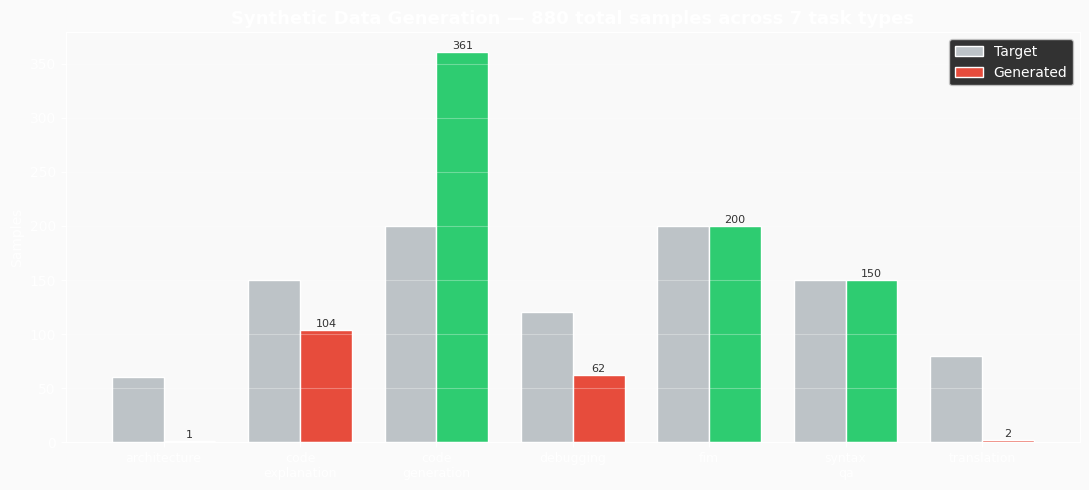

Saved: run/2026-03-25/08_synthetic_data_generation.png


In [22]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from datetime import date as _date

_run_dir = Path('.') / 'run' / _date.today().isoformat()
_run_dir.mkdir(parents=True, exist_ok=True)
_out = _run_dir / '08_synthetic_data_generation.png'

_tasks  = sorted(TARGETS.keys())
_target = [TARGETS[t] for t in _tasks]
_actual = [counts.get(t, 0) for t in _tasks]

x = np.arange(len(_tasks))
w = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, _target, w, label='Target', color='#bdc3c7', edgecolor='white')
b2 = ax.bar(x + w/2, _actual, w, label='Generated',
            color=['#2ecc71' if a >= t else '#e74c3c'
                   for a, t in zip(_actual, _target)],
            edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([t.replace('_', '\n') for t in _tasks], fontsize=9)
ax.set_ylabel('Samples')
ax.set_title(
    f'Synthetic Data Generation — {len(all_samples):,} total samples across {len(TARGETS)} task types',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
for bar in b2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 1, str(int(h)),
            ha='center', va='bottom', fontsize=8, color='#333')
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('#fafafa')
fig.tight_layout()
fig.savefig(_out, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved: {_out}')


In [23]:
# ── Samples per category ─────────────────────────────────────────────────────
import json, random
from collections import defaultdict

_pairs = []
if OUTPUT_FILE.exists():
    with open(OUTPUT_FILE) as f:
        for line in f:
            if line.strip():
                _pairs.append(json.loads(line))

_by_type = defaultdict(list)
for p in _pairs:
    _by_type[p.get('task_type', 'unknown')].append(p)

_CATEGORY_ORDER = [
    'code_generation',
    'code_explanation',
    'debugging',
    'syntax_qa',
    'translation',
    'architecture',
    'fim',
]
SAMPLES_PER_CAT = 2

for task_type in _CATEGORY_ORDER:
    pool = _by_type.get(task_type, [])
    if not pool:
        continue
    print(f'\n{"─"*72}')
    print(f'  {task_type}  ({len(pool)} pairs)')
    print('─'*72)
    for s in random.sample(pool, min(SAMPLES_PER_CAT, len(pool))):
        print(f'Q: {s["instruction"][:220]}')
        out = s.get('output', '')
        print(f'A: {out[:320]}{"..." if len(out) > 320 else ""}')
        print()


────────────────────────────────────────────────────────────────────────
  code_generation  (361 pairs)
────────────────────────────────────────────────────────────────────────
Q: features
A: ## main.aro
```aro
(* greetings.aro — Feature sets provided by plugin-swift-hello *)

(* Greet Feature — Say hello to someone *)
(Greet User: Greeting Handler) {
    Extract the <name> from the <request: name>.
    Greet the <greeting> with <name>.
    Return an <OK: status> with <greeting>.
}

(* Farewell Feature — Sa...

Q: ListTest
A: ## main.aro
```aro
(Application-Start: List Directory) {
    Create the <path> with ".".
    Log "Listing directory..." to the <console>.

    List the <entries> from the <directory: path>.
    Compute the <count: length> from the <entries>.

    Log "════════════════────────────────────────<count>════════════════" to ...


────────────────────────────────────────────────────────────────────────
  code_explanation  (104 pairs)
────────────────────────────────────

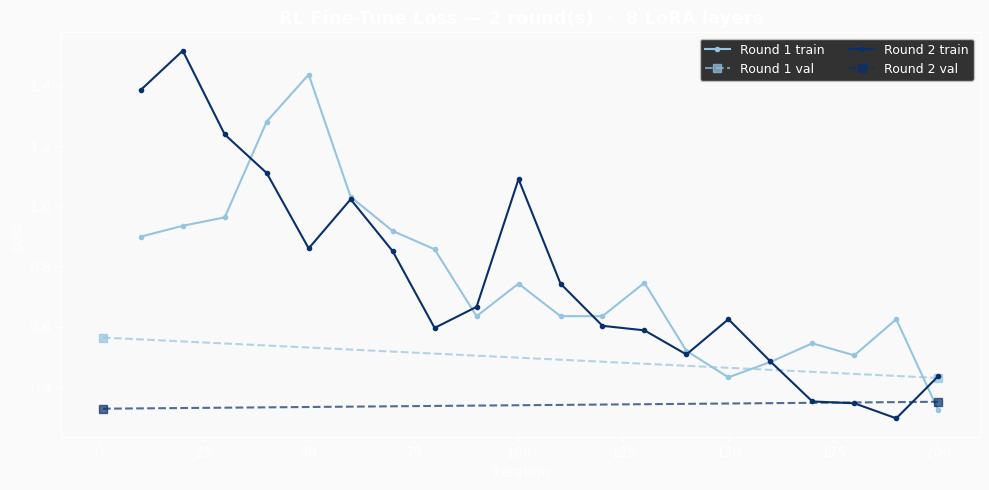

Saved: run/2026-03-25/10_rl_loss.png
  Rounds completed : 2
  Final adapter    : /Volumes/Models/data/../data/adapters/round_002


In [24]:
# ── Final status: RL fine-tune loss curves ────────────────────────────────────
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import date as _date

_run_dir = Path('.') / 'run' / _date.today().isoformat()
_run_dir.mkdir(parents=True, exist_ok=True)
_out = _run_dir / '10_rl_loss.png'

if not _rl_losses:
    print('No RL fine-tune rounds completed — skipping loss graph.')
    print(f'  Rounds run  : {_rl_round}')
    print(f'  RL adapter  : {_rl_adapter}')
else:
    _palette = plt.cm.Blues(
        [0.4 + 0.6 * i / max(1, len(_rl_losses) - 1) for i in range(len(_rl_losses))]
    )
    fig, ax = plt.subplots(figsize=(10, 5))

    for idx, (rnd, data) in enumerate(sorted(_rl_losses.items())):
        color = _palette[idx]
        if data['train_losses']:
            ax.plot(data['train_iters'], data['train_losses'],
                    '-o', ms=3, lw=1.5, color=color, label=f'Round {rnd} train')
        if data['val_losses']:
            ax.plot(data['val_iters'], data['val_losses'],
                    's--', ms=6, lw=1.5, color=color, alpha=0.7, label=f'Round {rnd} val')

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.set_title(
        f'RL Fine-Tune Loss — {len(_rl_losses)} round(s)  ·  {LORA_LAYERS} LoRA layers',
        fontsize=13, fontweight='bold'
    )
    ax.legend(fontsize=9, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_facecolor('#f9f9f9')
    fig.patch.set_facecolor('#fafafa')
    fig.tight_layout()
    fig.savefig(_out, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Saved: {_out}')
    print(f'  Rounds completed : {len(_rl_losses)}')
    print(f'  Final adapter    : {_rl_adapter}')
